In [36]:
%load_ext autoreload
%autoreload 2

from engine import Value
from visualize import draw_dot
from nn import MLP

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


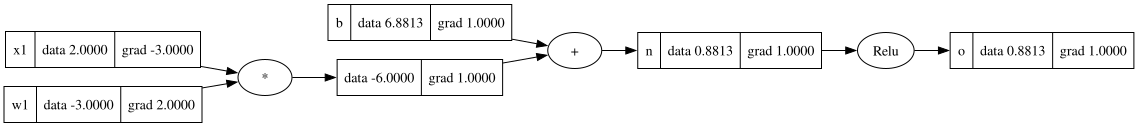

In [41]:
x1 = Value(2.0, label='x1')
w1 = Value(-3.0, label='w1')
b = Value(6.8813, label='b')

n = x1 * w1 + b; n.label = 'n'
o = n.relu(); o.label = 'o'
draw_dot(o)

o.backward()
draw_dot(o)

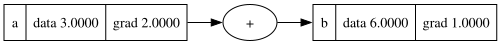

In [ ]:
# verify: f(a) = a + a -> df/da should be 2
a = Value(3.0, label='a')
b = a + a; b.label = 'b'

b.backward()

draw_dot(b)

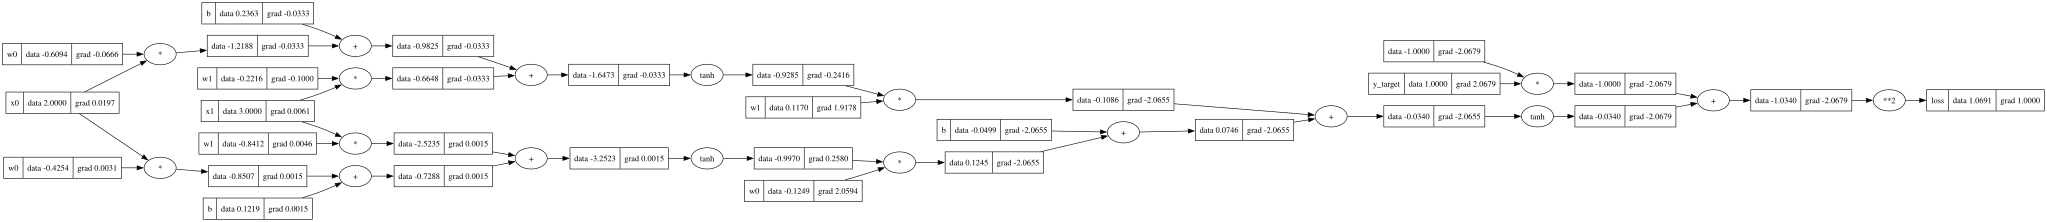

In [61]:
# 1. create MLP with input dim 2 -> hidden dim 2 -> output dim 1
model = MLP(2, [2, 1])

# 2. training data x [2.0, 3.0], target_y 1.0
x = [Value(2.0, label='x0'), Value(3.0, label='x1')]
y_target = Value(1.0, label='y_target')

# 3. compute loss 
y_predict = model(x)
loss = (y_predict - y_target) ** 2; loss.label = 'loss'

# 4. backprogation on loss
for p in model.parameters():
    p.grad = 0
loss.backward()

model.parameters()
draw_dot(loss)
